# Bangkok Next-Hour Rain Models

Train models from PostgreSQL table `"OM_BKK_DATA"` to predict whether each Bangkok grid point will receive rain in the next hour.

Models are in separate cells:
- Scikit-learn `HistGradientBoostingClassifier`
- LightGBM `LGBMClassifier`

The notebook also tests rainfall target thresholds such as `0.1`, `0.5`, `1.0`, and `2.0` mm for `next_hour_precipitation`.

## 1. Setup

In [1]:
# Optional: uncomment if needed.
# %pip install pandas psycopg2-binary scikit-learn lightgbm joblib matplotlib seaborn numpy

In [2]:
import json
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 2. Configuration

Change `RAIN_THRESHOLD_MM` to define what counts as rain in the next hour. Use `SAMPLE_ROWS` for quick experiments, then set it to `None` for full training.

In [3]:
DB_CONFIG = {
    "host": os.getenv("PGHOST", "localhost"),
    "port": int(os.getenv("PGPORT", "5432")),
    "dbname": os.getenv("PGDATABASE", "postgres"),
    "user": os.getenv("PGUSER", "postgres"),
    "password": os.getenv("PGPASSWORD", "Pass1234"),
}

TABLE_NAME = '"OM_BKK_DATA"'
MODEL_DIR = Path("../ML_Model_V2/trained_models/om_bkk_next_hour")

RAIN_THRESHOLD_MM = 0.1
PRECIPITATION_THRESHOLDS_TO_TEST = [0.1, 0.5, 1.0, 2.0, 5.0]
PROBABILITY_THRESHOLDS_TO_TEST = np.arange(0.10, 0.91, 0.05)

TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
SAMPLE_ROWS = None  # Example for quick runs: 300_000

RANDOM_STATE = 42

## 3. Load Features From PostgreSQL

Target is `next_hour_precipitation`, built with `LEAD(precipitation, 1)` per grid point. Lag and rolling features only use current/past hours.

In [4]:
FEATURE_COLUMNS = [
    "temperature_2m",
    "relative_humidity_2m",
    "pressure_msl",
    "surface_pressure",
    "dew_point_2m",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "temperature_dew_point_spread",
    "pressure_msl_change_3h",
    "precipitation_lag_1h",
    "precipitation_lag_2h",
    "precipitation_lag_3h",
    "precipitation_lag_6h",
    "precipitation_sum_past_3h",
    "precipitation_sum_past_6h",
    "precipitation_sum_past_24h",
    "cloud_cover_lag_1h",
    "cloud_cover_lag_3h",
    "humidity_lag_1h",
    "humidity_lag_3h",
    "wind_speed_lag_1h",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "grid_row",
    "grid_column",
    "latitude",
    "longitude",
]

def connect():
    return psycopg2.connect(**DB_CONFIG)

def read_training_data(sample_rows=None):
    query = f'''
    WITH features AS (
        SELECT
            grid_number,
            grid_row,
            grid_column,
            latitude,
            longitude,
            local_forecast_time AS forecast_time,
            temperature_2m,
            relative_humidity_2m,
            pressure_msl,
            surface_pressure,
            dew_point_2m,
            precipitation,
            cloud_cover,
            wind_speed_10m,
            wind_direction_10m,
            temperature_2m - dew_point_2m AS temperature_dew_point_spread,
            pressure_msl - LAG(pressure_msl, 3) OVER w AS pressure_msl_change_3h,
            LAG(precipitation, 1) OVER w AS precipitation_lag_1h,
            LAG(precipitation, 2) OVER w AS precipitation_lag_2h,
            LAG(precipitation, 3) OVER w AS precipitation_lag_3h,
            LAG(precipitation, 6) OVER w AS precipitation_lag_6h,
            SUM(precipitation) OVER (
                PARTITION BY grid_number ORDER BY local_forecast_time
                ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
            ) AS precipitation_sum_past_3h,
            SUM(precipitation) OVER (
                PARTITION BY grid_number ORDER BY local_forecast_time
                ROWS BETWEEN 5 PRECEDING AND CURRENT ROW
            ) AS precipitation_sum_past_6h,
            SUM(precipitation) OVER (
                PARTITION BY grid_number ORDER BY local_forecast_time
                ROWS BETWEEN 23 PRECEDING AND CURRENT ROW
            ) AS precipitation_sum_past_24h,
            LAG(cloud_cover, 1) OVER w AS cloud_cover_lag_1h,
            LAG(cloud_cover, 3) OVER w AS cloud_cover_lag_3h,
            LAG(relative_humidity_2m, 1) OVER w AS humidity_lag_1h,
            LAG(relative_humidity_2m, 3) OVER w AS humidity_lag_3h,
            LAG(wind_speed_10m, 1) OVER w AS wind_speed_lag_1h,
            LEAD(precipitation, 1) OVER w AS next_hour_precipitation,
            SIN(2 * pi() * EXTRACT(HOUR FROM local_forecast_time) / 24.0) AS hour_sin,
            COS(2 * pi() * EXTRACT(HOUR FROM local_forecast_time) / 24.0) AS hour_cos,
            SIN(2 * pi() * EXTRACT(MONTH FROM local_forecast_time) / 12.0) AS month_sin,
            COS(2 * pi() * EXTRACT(MONTH FROM local_forecast_time) / 12.0) AS month_cos
        FROM {TABLE_NAME}
        WINDOW w AS (PARTITION BY grid_number ORDER BY local_forecast_time)
    )
    SELECT *
    FROM features
    WHERE next_hour_precipitation IS NOT NULL
      AND pressure_msl_change_3h IS NOT NULL
      AND precipitation_lag_6h IS NOT NULL
      AND precipitation_sum_past_24h IS NOT NULL
      AND cloud_cover_lag_3h IS NOT NULL
      AND humidity_lag_3h IS NOT NULL
      AND wind_speed_lag_1h IS NOT NULL
    ORDER BY forecast_time, grid_number
    '''
    if sample_rows:
        query = f'''
        SELECT *
        FROM ({query}) complete_rows
        ORDER BY random()
        LIMIT {int(sample_rows)}
        '''
    with connect() as conn:
        return pd.read_sql_query(query, conn, parse_dates=["forecast_time"])

df = read_training_data(SAMPLE_ROWS)
print(f"Rows loaded: {len(df):,}")
print(f"Time range: {df['forecast_time'].min()} to {df['forecast_time'].max()}")
df.head()

C:\Users\Brandon\AppData\Local\Temp\ipykernel_20992\15975789.py:107: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn, parse_dates=["forecast_time"])


Rows loaded: 2,453,752
Time range: 2021-07-20 06:00:00 to 2026-07-19 22:00:00


,grid_number,grid_row,grid_column,latitude,longitude,forecast_time,temperature_2m,relative_humidity_2m,pressure_msl,surface_pressure,dew_point_2m,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,temperature_dew_point_spread,pressure_msl_change_3h,precipitation_lag_1h,precipitation_lag_2h,precipitation_lag_3h,precipitation_lag_6h,precipitation_sum_past_3h,precipitation_sum_past_6h,precipitation_sum_past_24h,cloud_cover_lag_1h,cloud_cover_lag_3h,humidity_lag_1h,humidity_lag_3h,wind_speed_lag_1h,next_hour_precipitation,hour_sin,hour_cos,month_sin,month_cos
0,1,1,1,13.4940,100.3270,2021-07-20 06:00:00,26.4000,87.0000,1005.6000,1005.4000,24.0000,2.4000,100.0000,18.0000,217.0000,2.4000,-0.3000,1.7000,1.0000,0.6000,0.3000,5.1000,6.2000,6.5000,99.0000,99.0000,87.0000,87.0000,19.7000,1.2000,1.0000,0.0000,-0.5000,-0.8660
1,2,1,2,13.4940,100.4102,2021-07-20 06:00:00,26.7000,85.0000,1005.7000,1005.7000,23.9000,2.0000,100.0000,19.2000,218.0000,2.8000,-0.3000,1.0000,0.4000,0.0000,0.3000,3.4000,3.6000,3.9000,99.0000,100.0000,82.0000,82.0000,23.2000,1.1000,1.0000,0.0000,-0.5000,-0.8660
2,3,1,3,13.4940,100.4934,2021-07-20 06:00:00,26.7000,85.0000,1005.7000,1005.7000,23.9000,2.0000,100.0000,19.2000,218.0000,2.8000,-0.3000,1.0000,0.4000,0.0000,0.3000,3.4000,3.6000,3.9000,99.0000,100.0000,82.0000,82.0000,23.2000,1.1000,1.0000,0.0000,-0.5000,-0.8660
3,4,1,4,13.4940,100.5767,2021-07-20 06:00:00,26.6000,86.0000,1005.8000,1005.8000,24.0000,1.4000,100.0000,18.3000,216.0000,2.6000,-0.2000,0.5000,0.1000,0.0000,0.4000,2.0000,2.3000,2.7000,100.0000,100.0000,82.0000,79.0000,23.2000,1.0000,1.0000,0.0000,-0.5000,-0.8660
4,5,1,5,13.4940,100.6599,2021-07-20 06:00:00,26.6000,86.0000,1005.8000,1005.8000,24.0000,1.4000,100.0000,18.3000,216.0000,2.6000,-0.2000,0.5000,0.1000,0.0000,0.4000,2.0000,2.3000,2.7000,100.0000,100.0000,82.0000,79.0000,23.2000,1.0000,1.0000,0.0000,-0.5000,-0.8660


## 4. Test Precipitation Target Thresholds

This checks how balanced the target is for different definitions of rain.

,rain_threshold_mm_next_hour,rows,rain_rows,no_rain_rows,rain_rate
0,0.1000,2453752,541154,1912598,0.2205
1,0.5000,2453752,208460,2245292,0.0850
2,1.0000,2453752,130073,2323679,0.0530
3,2.0000,2453752,69883,2383869,0.0285
4,5.0000,2453752,19932,2433820,0.0081


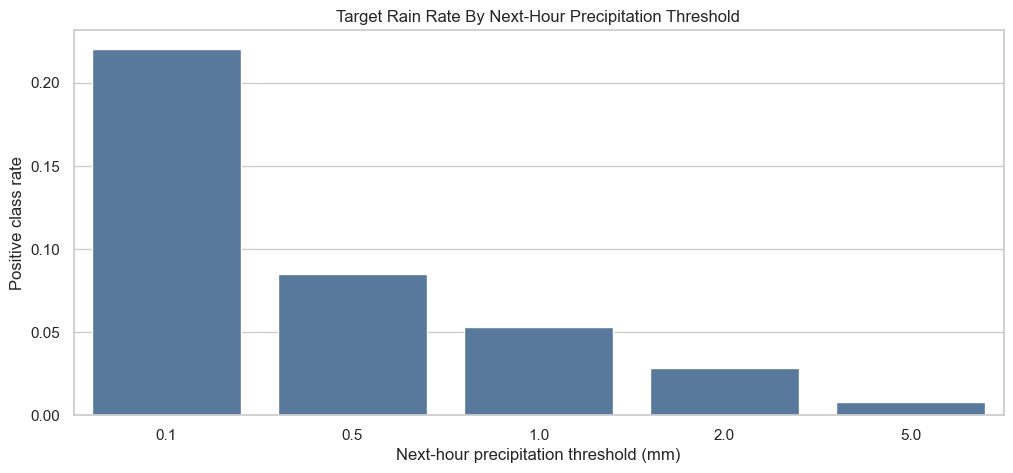

In [5]:
precip_threshold_results = []
for threshold in PRECIPITATION_THRESHOLDS_TO_TEST:
    y = (df["next_hour_precipitation"] >= threshold).astype("int8")
    precip_threshold_results.append({
        "rain_threshold_mm_next_hour": threshold,
        "rows": len(y),
        "rain_rows": int(y.sum()),
        "no_rain_rows": int((1 - y).sum()),
        "rain_rate": float(y.mean()),
    })

precip_threshold_df = pd.DataFrame(precip_threshold_results)
display(precip_threshold_df)

sns.barplot(data=precip_threshold_df, x="rain_threshold_mm_next_hour", y="rain_rate", color="#4c78a8")
plt.title("Target Rain Rate By Next-Hour Precipitation Threshold")
plt.xlabel("Next-hour precipitation threshold (mm)")
plt.ylabel("Positive class rate")
plt.show()

## 5. Split Data

The split is chronological to reduce leakage from future weather into past training.

In [6]:
def add_time_split(data, train_fraction=0.70, validation_fraction=0.15):
    unique_times = np.array(sorted(data["forecast_time"].unique()))
    train_end = unique_times[int(len(unique_times) * train_fraction)]
    validation_end = unique_times[int(len(unique_times) * (train_fraction + validation_fraction))]

    out = data.copy()
    out["target"] = (out["next_hour_precipitation"] >= RAIN_THRESHOLD_MM).astype("int8")
    out["split"] = "test"
    out.loc[out["forecast_time"] < train_end, "split"] = "train"
    out.loc[(out["forecast_time"] >= train_end) & (out["forecast_time"] < validation_end), "split"] = "validation"
    return out, train_end, validation_end

model_df, train_end, validation_end = add_time_split(df, TRAIN_FRACTION, VALIDATION_FRACTION)
print(f"Rain threshold: next_hour_precipitation >= {RAIN_THRESHOLD_MM} mm")
print(f"Train before: {train_end}")
print(f"Validation before: {validation_end}")
display(model_df.groupby("split")["target"].agg(rows="count", rain_rows="sum", rain_rate="mean").sort_index())

train_df = model_df[model_df["split"] == "train"]
validation_df = model_df[model_df["split"] == "validation"]
test_df = model_df[model_df["split"] == "test"]

x_train = train_df[FEATURE_COLUMNS].astype("float32")
y_train = train_df["target"].astype("int8")
x_validation = validation_df[FEATURE_COLUMNS].astype("float32")
y_validation = validation_df["target"].astype("int8")
x_test = test_df[FEATURE_COLUMNS].astype("float32")
y_test = test_df["target"].astype("int8")

Rain threshold: next_hour_precipitation >= 0.1 mm
Train before: 2025-01-18 05:00:00
Validation before: 2025-10-19 02:00:00


,rows,rain_rows,rain_rate
split,,,
test,368088,59703,0.1622
train,1717576,382511,0.2227
validation,368088,98940,0.2688


## 6. Evaluation Helpers

In [7]:
def base_metrics(y_true, probabilities, label):
    return {
        "split": label,
        "rows": int(len(y_true)),
        "rain_rate": float(np.mean(y_true)),
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
        "pr_auc": float(average_precision_score(y_true, probabilities)),
        "brier_score": float(brier_score_loss(y_true, probabilities)),
    }

def threshold_metrics(y_true, probabilities, thresholds=PROBABILITY_THRESHOLDS_TO_TEST):
    rows = []
    for threshold in thresholds:
        y_pred = (probabilities >= threshold).astype("int8")
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            "probability_threshold": float(threshold),
            "predicted_rain_rate": float(y_pred.mean()),
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
            "true_negatives": int(tn),
            "false_positives": int(fp),
            "false_negatives": int(fn),
            "true_positives": int(tp),
        })
    return pd.DataFrame(rows)

def evaluate_model(model, x, y, label):
    probabilities = model.predict_proba(x)[:, 1]
    metrics = base_metrics(y.to_numpy(), probabilities, label)
    thresholds = threshold_metrics(y.to_numpy(), probabilities)
    return probabilities, metrics, thresholds

def show_threshold_plot(results, title):
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.lineplot(data=results, x="probability_threshold", y="precision", marker="o", label="Precision", ax=ax)
    sns.lineplot(data=results, x="probability_threshold", y="recall", marker="o", label="Recall", ax=ax)
    sns.lineplot(data=results, x="probability_threshold", y="f1", marker="o", label="F1", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted probability threshold")
    ax.set_ylabel("Score")
    ax.legend()
    plt.show()

## 7. Model 1: HistGradientBoostingClassifier

,split,rows,rain_rate,roc_auc,pr_auc,brier_score
0,validation,368088,0.2688,0.8964,0.7805,0.1093
1,test,368088,0.1622,0.9158,0.7209,0.0770


,probability_threshold,predicted_rain_rate,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives
4,0.3000,0.1678,0.8887,0.6518,0.6741,0.6627,286882,21503,19458,40245
3,0.2500,0.1870,0.8818,0.6176,0.7123,0.6616,282060,26325,17178,42525
5,0.3500,0.1515,0.8934,0.6834,0.6382,0.6600,290730,17655,21601,38102
2,0.2000,0.2119,0.8703,0.5766,0.7533,0.6533,275363,33022,14726,44977
6,0.4000,0.1374,0.8956,0.7103,0.6016,0.6515,293734,14651,23784,35919
7,0.4500,0.1242,0.8964,0.7359,0.5636,0.6383,296307,12078,26055,33648
1,0.1500,0.2489,0.8499,0.5244,0.8048,0.6350,264803,43582,11655,48048
8,0.5000,0.1115,0.8956,0.7594,0.5220,0.6187,298511,9874,28537,31166
0,0.1000,0.3092,0.8093,0.4539,0.8654,0.5954,246220,62165,8039,51664
9,0.5500,0.0991,0.8940,0.7835,0.4786,0.5942,300488,7897,31128,28575


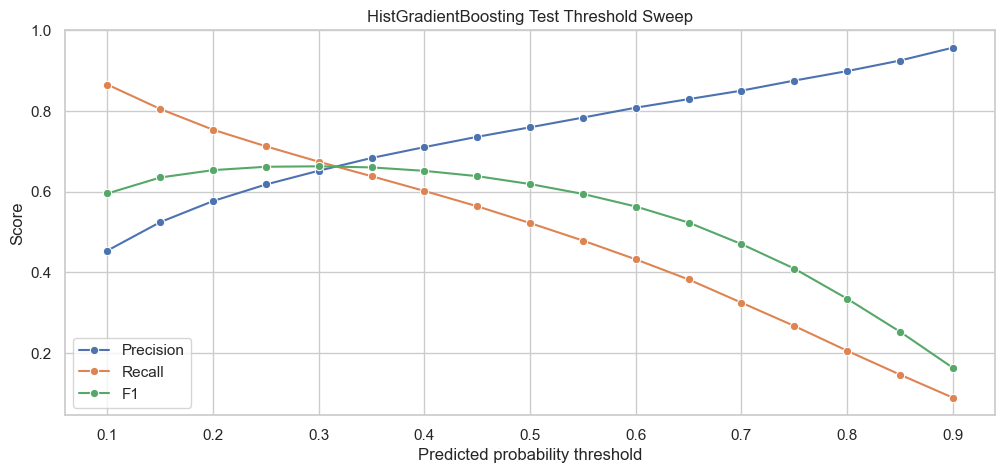

In [8]:
hist_model = HistGradientBoostingClassifier(
    learning_rate=0.06,
    max_iter=250,
    max_leaf_nodes=31,
    l2_regularization=0.05,
    random_state=RANDOM_STATE,
)

hist_model.fit(x_train, y_train)

hist_validation_prob, hist_validation_metrics, hist_validation_thresholds = evaluate_model(
    hist_model, x_validation, y_validation, "validation"
)
hist_test_prob, hist_test_metrics, hist_test_thresholds = evaluate_model(
    hist_model, x_test, y_test, "test"
)

display(pd.DataFrame([hist_validation_metrics, hist_test_metrics]))
display(hist_test_thresholds.sort_values("f1", ascending=False).head(10))
show_threshold_plot(hist_test_thresholds, "HistGradientBoosting Test Threshold Sweep")

## 8. Model 2: LightGBM

[LightGBM] [Info] Number of positive: 382511, number of negative: 1335065
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.160244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4124
[LightGBM] [Info] Number of data points in the train set: 1717576, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.222704 -> initscore=-1.249978
[LightGBM] [Info] Start training from score -1.249978


,split,rows,rain_rate,roc_auc,pr_auc,brier_score
0,validation,368088,0.2688,0.8979,0.7818,0.1351
1,test,368088,0.1622,0.9168,0.7221,0.0882


,probability_threshold,predicted_rain_rate,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives
9,0.5500,0.1790,0.8848,0.6312,0.6967,0.6623,284077,24308,18108,41595
10,0.6000,0.1627,0.8901,0.6608,0.6628,0.6618,288070,20315,20133,39570
8,0.5000,0.1965,0.8778,0.6018,0.7290,0.6593,279591,28794,16179,43524
11,0.6500,0.1475,0.8940,0.6906,0.6280,0.6578,291588,16797,22208,37495
7,0.4500,0.2157,0.8690,0.5723,0.7610,0.6533,274431,33954,14269,45434
12,0.7000,0.1326,0.8963,0.7204,0.5891,0.6482,294734,13651,24530,35173
6,0.4000,0.2356,0.8580,0.5428,0.7885,0.6430,268733,39652,12630,47073
5,0.3500,0.2584,0.8444,0.5128,0.8171,0.6302,262042,46343,10919,48784
13,0.7500,0.1165,0.8965,0.7519,0.5399,0.6285,297751,10634,27467,32236
4,0.3000,0.2855,0.8269,0.4809,0.8465,0.6133,253823,54562,9163,50540


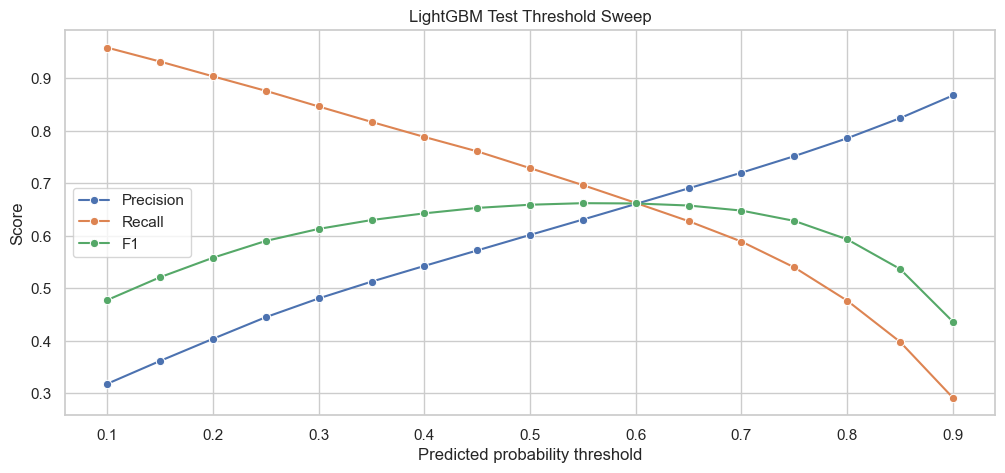

In [9]:
try:
    from lightgbm import LGBMClassifier
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Install LightGBM first: %pip install lightgbm") from exc

scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))

lgbm_model = LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.04,
    num_leaves=63,
    min_child_samples=80,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

lgbm_model.fit(
    x_train,
    y_train,
    eval_set=[(x_validation, y_validation)],
    eval_metric="binary_logloss",
)

lgbm_validation_prob, lgbm_validation_metrics, lgbm_validation_thresholds = evaluate_model(
    lgbm_model, x_validation, y_validation, "validation"
)
lgbm_test_prob, lgbm_test_metrics, lgbm_test_thresholds = evaluate_model(
    lgbm_model, x_test, y_test, "test"
)

display(pd.DataFrame([lgbm_validation_metrics, lgbm_test_metrics]))
display(lgbm_test_thresholds.sort_values("f1", ascending=False).head(10))
show_threshold_plot(lgbm_test_thresholds, "LightGBM Test Threshold Sweep")

## 9. Compare Models

In [10]:
comparison = pd.DataFrame([
    {"model": "hist_gradient_boosting", **hist_test_metrics},
    {"model": "lightgbm", **lgbm_test_metrics},
])
display(comparison)

best_hist_threshold = hist_test_thresholds.sort_values("f1", ascending=False).iloc[0]
best_lgbm_threshold = lgbm_test_thresholds.sort_values("f1", ascending=False).iloc[0]
display(pd.DataFrame([
    {"model": "hist_gradient_boosting", **best_hist_threshold.to_dict()},
    {"model": "lightgbm", **best_lgbm_threshold.to_dict()},
]))

,model,split,rows,rain_rate,roc_auc,pr_auc,brier_score
0,hist_gradient_boosting,test,368088,0.1622,0.9158,0.7209,0.0770
1,lightgbm,test,368088,0.1622,0.9168,0.7221,0.0882


,model,probability_threshold,predicted_rain_rate,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives
0,hist_gradient_boosting,0.3000,0.1678,0.8887,0.6518,0.6741,0.6627,286882.0000,21503.0000,19458.0000,40245.0000
1,lightgbm,0.5500,0.1790,0.8848,0.6312,0.6967,0.6623,284077.0000,24308.0000,18108.0000,41595.0000


## 10. Feature Importance

LightGBM exposes built-in feature importance. HistGradientBoosting does not, so use permutation importance later if you need it.

,feature,importance
2,pressure_msl,2885
8,wind_direction_10m,2232
10,pressure_msl_change_3h,2088
4,dew_point_2m,1874
0,temperature_2m,1846
23,hour_sin,1741
24,hour_cos,1636
25,month_sin,1537
7,wind_speed_10m,1349
26,month_cos,1278


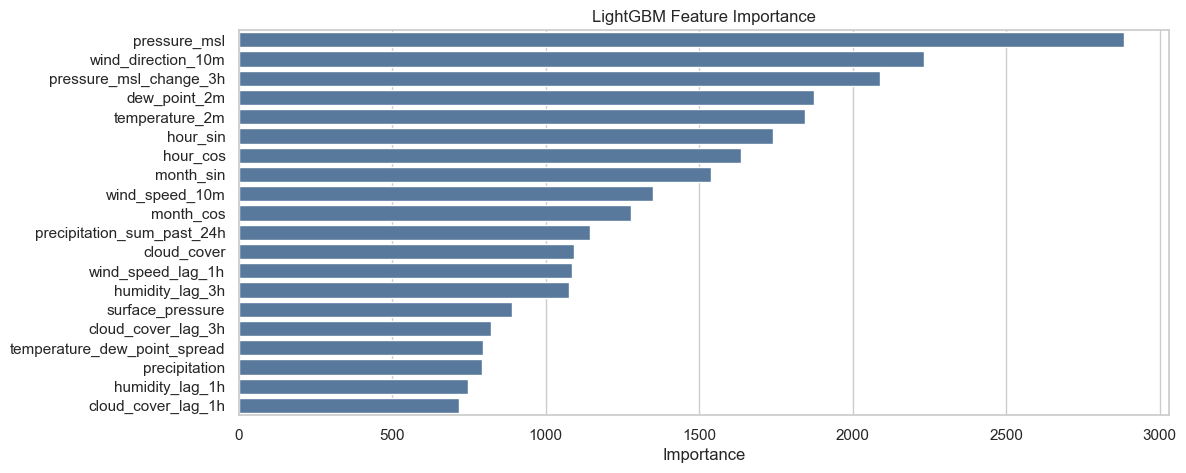

In [11]:
lgbm_importance = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance": lgbm_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(lgbm_importance.head(25))

sns.barplot(data=lgbm_importance.head(20), y="feature", x="importance", color="#4c78a8")
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("")
plt.show()

## 11. Save Models And Metadata

In [12]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

hist_model_path = MODEL_DIR / f"om_bkk_next_1h_rain_histgbm_threshold_{RAIN_THRESHOLD_MM:g}mm.joblib"
lgbm_model_path = MODEL_DIR / f"om_bkk_next_1h_rain_lightgbm_threshold_{RAIN_THRESHOLD_MM:g}mm.joblib"
metadata_path = MODEL_DIR / f"om_bkk_next_1h_rain_metadata_threshold_{RAIN_THRESHOLD_MM:g}mm.json"

joblib.dump(hist_model, hist_model_path)
joblib.dump(lgbm_model, lgbm_model_path)

metadata = {
    "table": TABLE_NAME,
    "target": "next_hour_precipitation",
    "rain_threshold_mm": RAIN_THRESHOLD_MM,
    "feature_columns": FEATURE_COLUMNS,
    "train_end_exclusive": str(train_end),
    "validation_end_exclusive": str(validation_end),
    "sample_rows": SAMPLE_ROWS,
    "hist_gradient_boosting": {
        "model_path": str(hist_model_path),
        "validation_metrics": hist_validation_metrics,
        "test_metrics": hist_test_metrics,
        "best_test_probability_threshold_by_f1": best_hist_threshold.to_dict(),
    },
    "lightgbm": {
        "model_path": str(lgbm_model_path),
        "validation_metrics": lgbm_validation_metrics,
        "test_metrics": lgbm_test_metrics,
        "best_test_probability_threshold_by_f1": best_lgbm_threshold.to_dict(),
    },
    "precipitation_threshold_results": precip_threshold_df.to_dict(orient="records"),
}

metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

hist_validation_thresholds.to_csv(MODEL_DIR / "histgbm_validation_probability_thresholds.csv", index=False)
hist_test_thresholds.to_csv(MODEL_DIR / "histgbm_test_probability_thresholds.csv", index=False)
lgbm_validation_thresholds.to_csv(MODEL_DIR / "lightgbm_validation_probability_thresholds.csv", index=False)
lgbm_test_thresholds.to_csv(MODEL_DIR / "lightgbm_test_probability_thresholds.csv", index=False)

print(f"Saved HistGradientBoosting model: {hist_model_path}")
print(f"Saved LightGBM model: {lgbm_model_path}")
print(f"Saved metadata: {metadata_path}")

Saved HistGradientBoosting model: ..\ML_Model_V2\trained_models\om_bkk_next_hour\om_bkk_next_1h_rain_histgbm_threshold_0.1mm.joblib
Saved LightGBM model: ..\ML_Model_V2\trained_models\om_bkk_next_hour\om_bkk_next_1h_rain_lightgbm_threshold_0.1mm.joblib
Saved metadata: ..\ML_Model_V2\trained_models\om_bkk_next_hour\om_bkk_next_1h_rain_metadata_threshold_0.1mm.json
